In [3]:
import pandas as pd
categoria = 'fund'
modelo1 = 'NB_S_VOL'
modelo2 = 'HT'
df1 = pd.read_csv(f'resultados/resultados_{modelo1}.csv')
df_vmob = pd.read_csv('/home/jjos/profit_performance/valor_mobiliario.csv')
# ensure the column is datetime-like before using .dt
if not pd.api.types.is_datetime64_any_dtype(df_vmob['Data_Referencia']):
    df_vmob['Data_Referencia'] = pd.to_datetime(df_vmob['Data_Referencia'], errors='coerce')

papeis = df_vmob[df_vmob['Data_Referencia'].dt.year == 2023].Codigo_Negociacao.unique()
df1 = df1[df1['base'].isin(papeis)]
df1 = df1[~df1['base'].isin(['LEVE3', 'LEVE4'])]  # Exclude LEVE3 and LEVE4 due to not ajusted prices
df2 = pd.read_csv(f'resultados/resultados_{modelo2}.csv')
df2 = df2[df2['base'].isin(papeis)]
df2 = df2[~df2['base'].isin(['LEVE3', 'LEVE4'])]  # Exclude LEVE3 and LEVE4 due to not ajusted prices
df1_categoria = df1[df1['categoria'] == categoria]
df2_categoria = df2[df2['categoria'] == categoria]
df1_categoria_mean = df1_categoria.mean()
df2_categoria_mean = df2_categoria.mean()
comparison = pd.DataFrame({
    modelo1: df1_categoria_mean,
    modelo2: df2_categoria_mean
})
# df2[['Accuracy', 'Kappa', 'G-Mean', 'Recall', 'Precision',
#        'TP', 'TN', 'FP', 'FN', 'KappaM', 'base', 'modelo', 'categoria', 'fh']].sort_values(by='Kappa', ascending=True).head(550).base.unique()

Tabela de Dados:
categoria      fund  nao_fund_s_vol
fh                                 
1.0        0.004607        0.004607
30.0       0.000024        0.000024
60.0       0.004620        0.004620
90.0      -0.009316       -0.009316
120.0     -0.006990       -0.006990
150.0      0.002709        0.002709
180.0     -0.009378       -0.009378
210.0     -0.022266       -0.022266
240.0     -0.042028       -0.040217
------------------------------


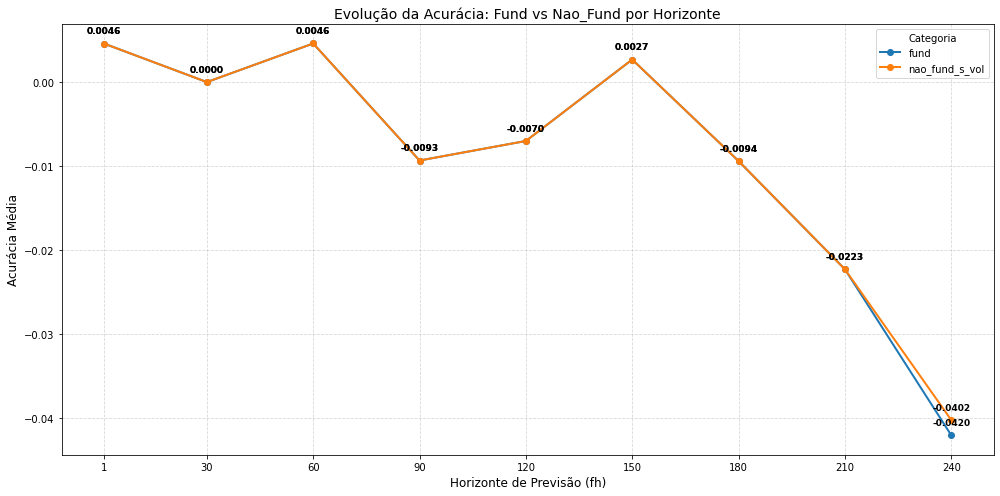

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configurações e Filtros
horizontes_desejados = [1, 30, 60, 90, 120, 150, 180, 210, 240]
colunas_interesse = ['Kappa', 'Accuracy', 'categoria', 'fh']

# Copia e filtra os dados
df_filtro = df1[colunas_interesse].copy()
df_filtro = df_filtro[df_filtro['categoria'].isin(['fund', 'nao_fund_s_vol'])]
df_filtro = df_filtro[df_filtro['fh'].isin(horizontes_desejados)]

# 2. Agrupamento (Tabela Pivô)
# Cria a tabela onde o índice é o horizonte e as colunas são as categorias
df_comparacao = df_filtro.groupby(['fh', 'categoria'])['Kappa'].mean().unstack()

print("Tabela de Dados:")
print(df_comparacao)
print("-" * 30)

# 3. Plotagem do Gráfico de Linha
# marker='o' adiciona as bolinhas nos pontos
ax = df_comparacao.plot(kind='line', marker='o', figsize=(14, 7), linewidth=2)

plt.title('Evolução da Acurácia: Fund vs Nao_Fund por Horizonte', fontsize=14)
plt.ylabel('Acurácia Média', fontsize=12)
plt.xlabel('Horizonte de Previsão (fh)', fontsize=12)
plt.legend(title='Categoria')
plt.grid(True, linestyle='--', alpha=0.5)

# Define os ticks do eixo X para serem exatamente os seus horizontes
plt.xticks(df_comparacao.index) 

# 4. Adicionando os Valores (Anotações para Linhas)
# Percorre cada coluna (categoria) e cada ponto (x, y)
for categoria in df_comparacao.columns:
    for x, y in zip(df_comparacao.index, df_comparacao[categoria]):
        # Formata o valor e define a posição
        label = f"{y:.4f}"
        
        # Anota no gráfico
        ax.annotate(label, 
                    (x, y), 
                    textcoords="offset points", 
                    xytext=(0, 10), # Desloca o texto 10 pontos para cima
                    ha='center',
                    fontsize=9,
                    fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
df_horizon.Accuracy.mean()

0.4986619175944877